In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
import nltk
from nltk.corpus import stopwords

In [2]:
def clean_text(text: str) -> str:
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    # Remove punctuation (keep only letters and spaces)
    text = re.sub(r"[^a-z\s]", "", text)
    # Tokenize by whitespace
    tokens = text.split()
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # Join back into string
    return " ".join(tokens)

In [3]:
CSV_PATH = "datasets/spam.csv"
try:
    stop_words = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords")
    stop_words = set(stopwords.words("english"))
df = pd.read_csv(CSV_PATH, encoding="latin-1")
print("Original columns:", df.columns.tolist())
print(df.head(), "\n")
# v1 = label ('ham'/'spam'), v2 = text, others are junk columns
if "v1" in df.columns and "v2" in df.columns:
    df = df[["v1", "v2"]]
    df = df.rename(columns={"v1": "label", "v2": "text"})
else:
    #df.rename(columns={"Category": "label", "Message": "text"}, inplace=True)
    raise ValueError("Unexpected column names. Please adjust the script to match your CSV.")
# Drop missing values
df = df.dropna(subset=["label", "text"]).reset_index(drop=True)
print("Dataset shape after cleaning:", df.shape)
print(df["label"].value_counts(), "\n")

Original columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN   

Dataset shape after cleaning: (5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64 



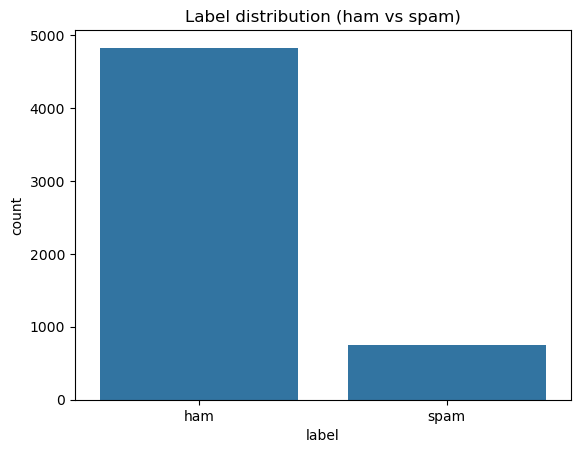

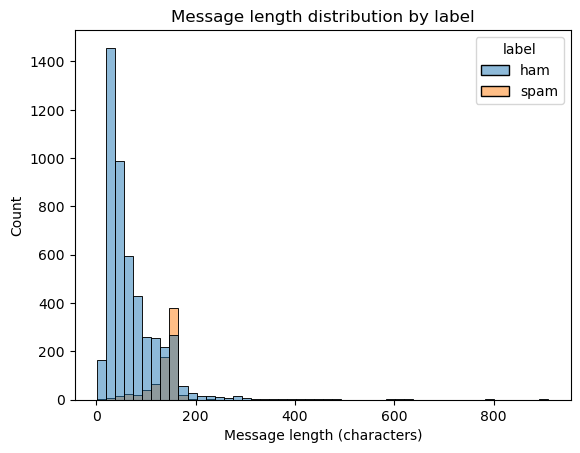

In [5]:
# Label distribution
plt.figure()
sns.countplot(x="label", data=df)
plt.title("Label distribution (ham vs spam)")
plt.show()
# Message length analysis
df["length"] = df["text"].str.len()
plt.figure()
sns.histplot(data=df, x="length", hue="label", bins=50, kde=False)
plt.title("Message length distribution by label")
plt.xlabel("Message length (characters)")
plt.ylabel("Count")
plt.show()

In [6]:
print("Cleaning text...")
df["text_clean"] = df["text"].astype(str).apply(clean_text)
print("Sample original vs cleaned:")
for i in range(3):
    print("Original:", df["text"].iloc[i])
    print("Cleaned :", df["text_clean"].iloc[i])
    print("---")

Cleaning text...
Sample original vs cleaned:
Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned : go jurong point crazy available bugis n great world la e buffet cine got amore wat
---
Original: Ok lar... Joking wif u oni...
Cleaned : ok lar joking wif u oni
---
Original: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned : free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply overs
---


In [7]:
X = df["text_clean"].values
y = df["label"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))


Train size: 3900
Test size: 1672


In [ ]:
print("\n=== Baseline: DummyClassifier (most_frequent) ===")
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train.reshape(-1, 1), y_train)
y_pred_dummy = dummy.predict(X_test.reshape(-1, 1))
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))


=== Baseline: DummyClassifier (most_frequent) ===
Accuracy: 0.8660287081339713



=== Bag-of-Words + MultinomialNB ===
Vocabulary size (BoW): 6849
Accuracy: 0.9766746411483254

Classification report (BoW + NB):
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99      1448
        spam       0.93      0.89      0.91       224

    accuracy                           0.98      1672
   macro avg       0.96      0.94      0.95      1672
weighted avg       0.98      0.98      0.98      1672



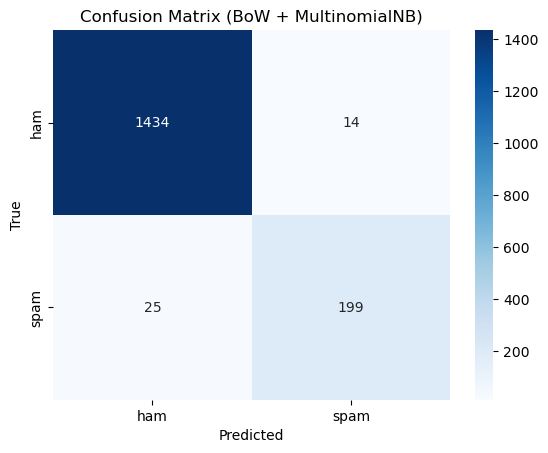

In [9]:
print("\n=== Bag-of-Words + MultinomialNB ===")
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)
print("Vocabulary size (BoW):", len(bow_vectorizer.vocabulary_))
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)
print("Accuracy:", accuracy_score(y_test, y_pred_nb_bow))
print("\nClassification report (BoW + NB):")
print(classification_report(y_test, y_pred_nb_bow))
cm_bow = confusion_matrix(y_test, y_pred_nb_bow)
plt.figure()
sns.heatmap(cm_bow, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.title("Confusion Matrix (BoW + MultinomialNB)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


=== TF-IDF + Logistic Regression ===
Vocabulary size (TF-IDF): 6849
Accuracy: 0.9581339712918661

Classification report (TF-IDF + LogisticRegression):
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1448
        spam       0.98      0.71      0.82       224

    accuracy                           0.96      1672
   macro avg       0.97      0.85      0.90      1672
weighted avg       0.96      0.96      0.96      1672



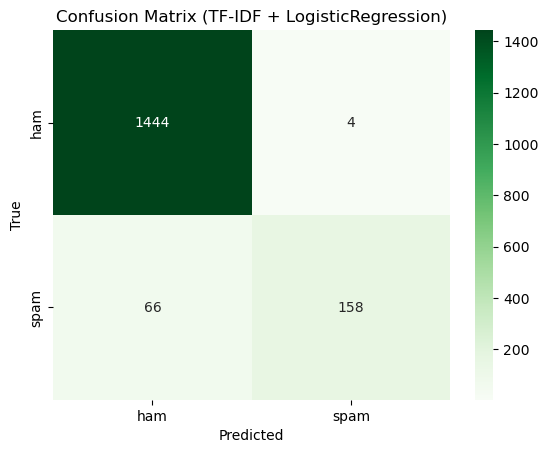


Done.


In [10]:
print("\n=== TF-IDF + Logistic Regression ===")
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print("Vocabulary size (TF-IDF):", len(tfidf_vectorizer.vocabulary_))
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_tfidf, y_train)
y_pred_lr = log_reg.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification report (TF-IDF + LogisticRegression):")
print(classification_report(y_test, y_pred_lr))
cm_tfidf = confusion_matrix(y_test, y_pred_lr)
plt.figure()
sns.heatmap(cm_tfidf, annot=True, fmt="d", cmap="Greens", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.title("Confusion Matrix (TF-IDF + LogisticRegression)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nDone.")